In [1]:
import pandas as pd
import matplotlib.pyplot as plt

branches = pd.read_csv("../data/clean/branches_clean.csv")

In [2]:
branches.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   branch_id    100 non-null    str  
 1   branch_name  100 non-null    str  
 2   city         100 non-null    str  
 3   state        100 non-null    str  
 4   region       100 non-null    str  
 5   employees    100 non-null    int64
dtypes: int64(1), str(5)
memory usage: 4.8 KB


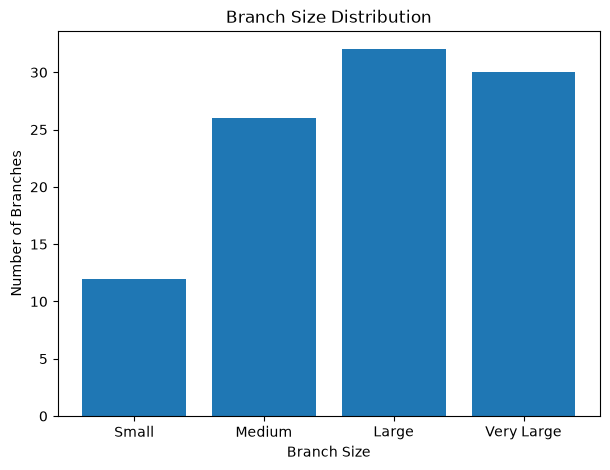

In [4]:
branches["branch_size"] = pd.cut(
    branches["employees"],
    bins=[0, 50, 100, 150, 250],
    labels=["Small", "Medium", "Large", "Very Large"]
)

branch_size = branches["branch_size"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(branch_size.index.astype(str), branch_size.values)

plt.title("Branch Size Distribution")
plt.xlabel("Branch Size")
plt.ylabel("Number of Branches")

plt.show()

Large branches lead the network: Large branches make up the biggest single group at 32 branches, closely followed by Very Large branches at 30.

Medium branches form a strong secondary tier: Medium branches account for 26 locations, showing a substantial mid-sized footprint.

Small branches are a minority: Small branches represent the smallest category by far with only 12 locations.

Key takeaway: The network is heavily skewed toward high-capacity hubs (Large and Very Large branches comprise over 60% of total locations), reflecting a centralized service model built to handle high foot traffic and volume.

In [5]:
branches["employee_category"] = pd.cut(
    branches["employees"],
    bins=[0,75,125,175,250],
    labels=["Low","Average","High","Very High"]
)

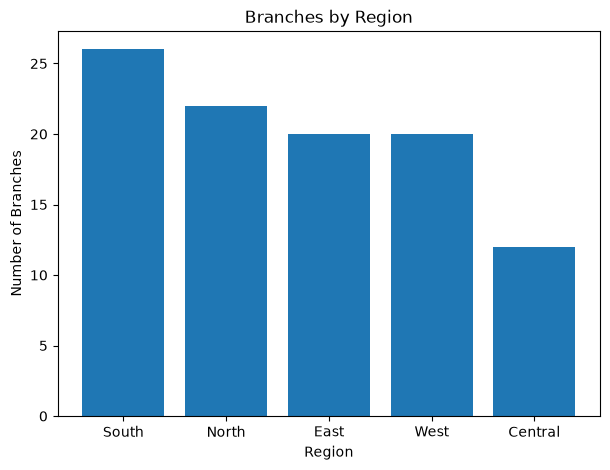

In [6]:
region = branches["region"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(region.index, region.values)

plt.title("Branches by Region")
plt.xlabel("Region")
plt.ylabel("Number of Branches")

plt.show()

South leads the network: The South region has the highest concentration of branches at 26 locations.

North, East, and West form a solid core: North follows closely with 22 branches, while East and West maintain an equal share with 20 branches each.

Central lags behind: The Central region has the smallest coverage with only 12 branches.

Key takeaway: Physical branch presence is heavily focused in Southern and Northern territories, highlighting a potential opportunity to expand coverage or digital outreach in the Central region.

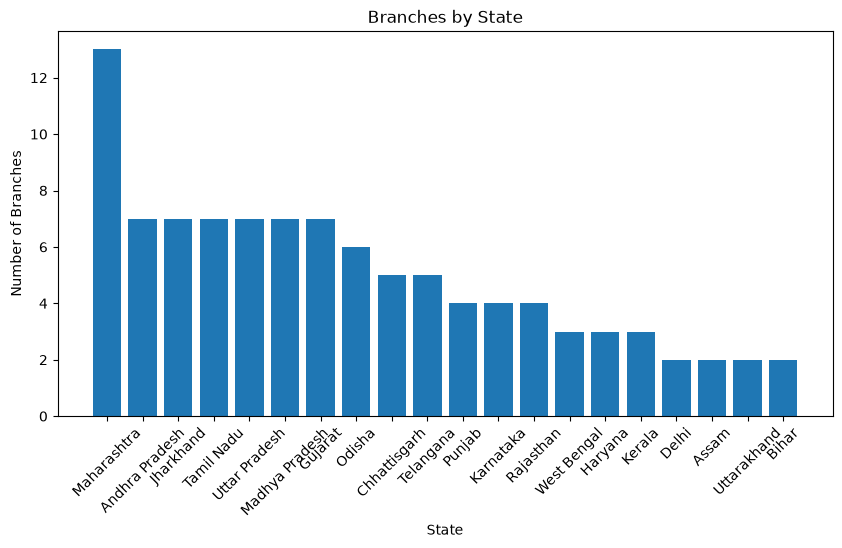

In [7]:
state = branches["state"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(state.index, state.values)

plt.xticks(rotation=45)

plt.title("Branches by State")
plt.xlabel("State")
plt.ylabel("Number of Branches")

plt.show()

Maharashtra dominates branch count: Maharashtra leads the network by a huge margin with 13 branches—nearly double the count of any other state.

Large secondary cluster: A steady cluster of six states—Andhra Pradesh, Jharkhand, Tamil Nadu, Uttar Pradesh, Madhya Pradesh, and Gujarat—follows with 7 branches each.

Gradual tail down to regional hubs: Branch density steps down through Odisha (6), Chhattisgarh and Telangana (5 each), down to smaller markets like Delhi, Assam, Uttarakhand, and Bihar with 2 branches each.

Key takeaway: Physical presence is highly concentrated in Maharashtra, while the rest of the network is evenly spread across major Indian growth states.

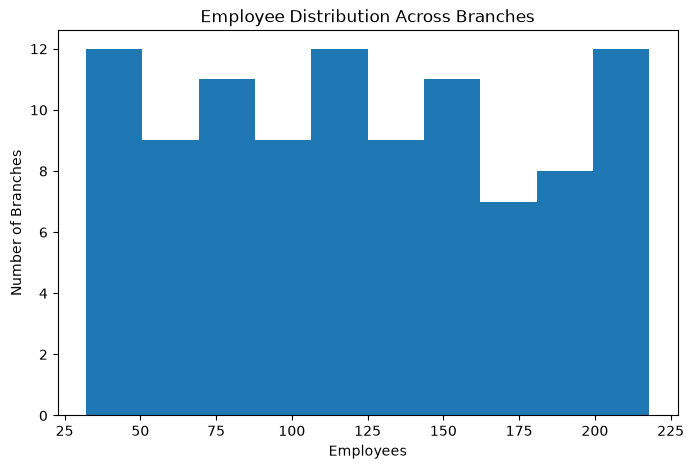

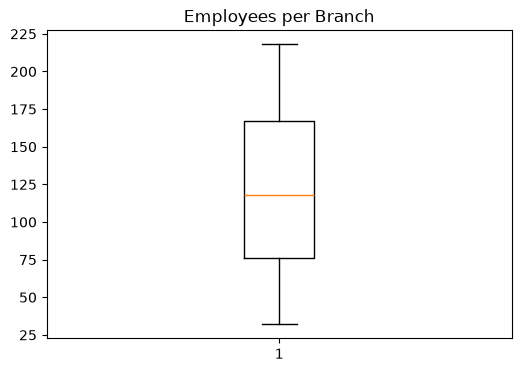

In [9]:
plt.figure(figsize=(8,5))
plt.hist(branches["employees"], bins=10)

plt.title("Employee Distribution Across Branches")
plt.xlabel("Employees")
plt.ylabel("Number of Branches")

plt.show()



plt.figure(figsize=(6,4))
plt.boxplot(branches["employees"])

plt.title("Employees per Branch")

plt.show()

Fairly uniform distribution: Staffing levels range from around 30 to 220 employees per branch, with relatively consistent representation across all bin sizes.

Peak staffing tiers: The highest concentration of branches (12 branches each) falls into three staff ranges: 30–50 employees, 110–125 employees, and 200–218 employees.

Slight dip in mid-high tier: The 165–180 employee range sees the lowest frequency, with only 7 branches falling into this bracket.

Key takeaway: The network operates with a wide spectrum of workforce sizes—from lean localized teams to high-capacity operational hubs—ensuring flexibility across different market demands.

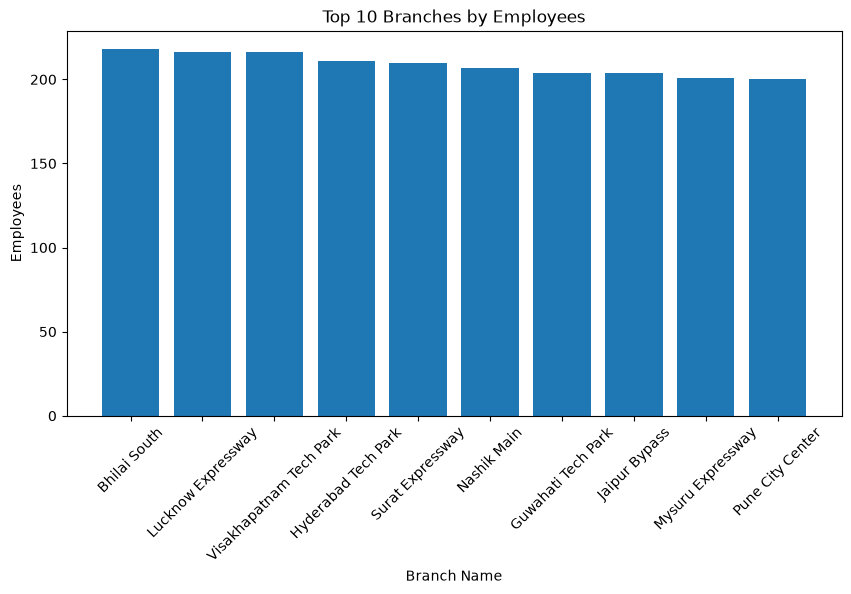

In [10]:
top = branches.nlargest(10, "employees")

plt.figure(figsize=(10,5))
plt.bar(top["branch_name"], top["employees"])

plt.xticks(rotation=45)

plt.title("Top 10 Branches by Employees")
plt.xlabel("Branch Name")
plt.ylabel("Employees")

plt.show()

Top staffing leader: Bhilai South tops the list with the highest staff count, reaching approximately 218 employees.

Tight, high-capacity cluster: Lucknow Expressway and Visakhapatnam Tech Park follow closely with around 216 employees each.

Highly balanced top tier: Staffing across all top 10 locations is extremely consistent, ranging narrowly between 200 employees (Pune City Center) and 218 employees (Bhilai South).

Key takeaway: These major branches—primarily tech parks, expressways, and urban centers—serve as high-capacity operational hubs handling the largest workforce allocations across the network.

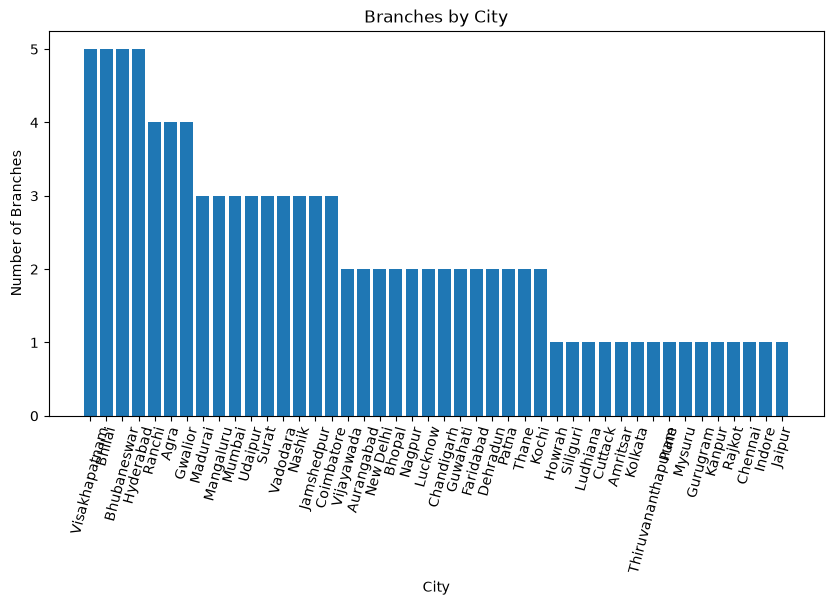

In [17]:
city = branches["city"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(city.index, city.values)

plt.xticks(rotation=75)

plt.title("Branches by City")
plt.xlabel("City")
plt.ylabel("Number of Branches")

plt.show()

Top urban hubs: Visakhapatnam, Bhilai, Bhubaneswar, and Hyderabad lead the network with the highest density of 5 branches each.

Tiered city distribution: Branch coverage steps down smoothly from 4 branches (Ranchi, Agra, Gwalior) to 3 branches (Mumbai, Surat, Nashik, etc.) and 2 branches across major commercial centers.

Broad single-branch reach: A wide array of cities—including Kolkata, Chennai, Jaipur, Pune, and Gurugram—are currently served by 1 branch each.

Key takeaway: The bank uses a multi-tier expansion model, concentrating presence in key growth hubs while maintaining single-branch touchpoints across dozens of regional markets.

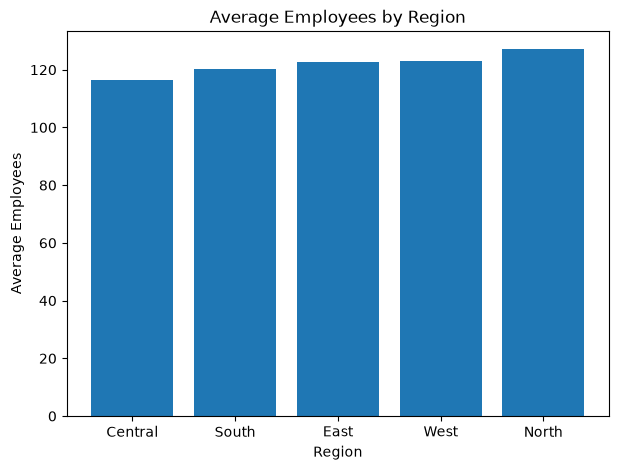

In [18]:
avg_emp = branches.groupby("region")["employees"].mean().sort_values()

plt.figure(figsize=(7,5))
plt.bar(avg_emp.index, avg_emp.values)

plt.title("Average Employees by Region")
plt.xlabel("Region")
plt.ylabel("Average Employees")

plt.show()

Remarkably balanced regional staffing: The average headcount per branch is exceptionally uniform across all territories, ranging tightly between 116 and 127 employees.

North leads slightly: The North region has the highest average branch size at roughly 127 employees, followed closely by East and West at around 123 employees each.

Central is marginally leaner: Central branches average the fewest staff members at approximately 116 employees, with South just above at 120 employees.

Key takeaway: Staffing allocation per branch is highly standardized across the entire country, regardless of geographic region or total branch count.

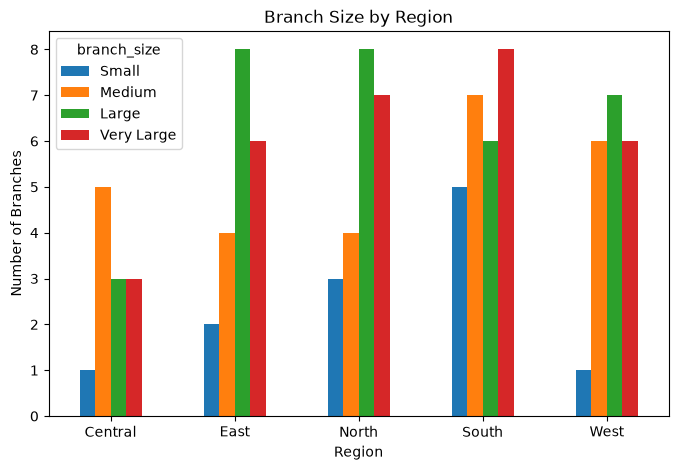

In [19]:
branch_region = pd.crosstab(
    branches["region"],
    branches["branch_size"]
)

branch_region.plot(kind="bar", figsize=(8,5))

plt.title("Branch Size by Region")
plt.xlabel("Region")
plt.ylabel("Number of Branches")

plt.xticks(rotation=0)

plt.show()

Large & Very Large hubs dominate major regions: East, North, and South host the highest concentration of major hubs, peaking with 8 Large branches in East & North and 8 Very Large branches in South.

South holds the most balanced & largest network: South has the highest count of Very Large (8), Medium (7), and Small (5) branches, representing the most diverse regional setup.

Central leans toward mid-sized locations: Unlike other territories, Central is driven primarily by Medium branches (5), with relatively few Large and Very Large locations (3 each).

Key takeaway: High-capacity operations are heavily clustered in East, North, and South, while Central operates primarily as a mid-scale regional network.